# United States — F-Score grid study: k ∈ {20, 25, 30} × N ∈ {1000, 2000, 5000}

The United States share of the grid: basket sizes × random-sample sizes × three
markets, 27 cells in all. The nine United States cells run in this one notebook;
each writes `results/grid/us_k{k}_mc{N}_*.csv` and its four figures
exactly as before, so the per-cell outputs are unchanged.

Signals come from SEC EDGAR XBRL statements — public filings, no vendor
involved — screened to the S&P 500 constituent list as of each formation
and scored by this repository's own signal code (`fscore.signal.piotroski`,
unit-tested, beginning-of-year asset scaling on both sides of every delta);
prices from the cached Yahoo data. This is the same source notebook 03
reads, so the grid varies k and N against the reported dataset.

Formations are July 1 of **2012–2024** (13 chained holding years, each a full
twelve months) using score year T−1 — one conservative timing rule for every
market, over identical calendar time so the three are comparable. July 2024 is
the last formation whose complete year finishes inside the sample. Covariances
are estimated on 36 months of daily returns ending the day before formation.

Note the panel resolves to *currently listed* symbols, so the
universe is survivorship-tilted — disclosed as a data limitation.
The value control falls back to the universe in years before B/M
coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW and
plain universe minimum-variance controls; a dollar-neutral long-short book (long top-k scores, short bottom-k, charged
both legs' trading costs plus a stock-borrow fee), tradable here; denoised (not detoned) GMV; primary
measure fixed in advance = the GROSS Sharpe ratio (rf = 0), with turnover and
net-of-cost figures reported separately; and the synergy test
D = Sharpe(GMV) − Sharpe(EW) computed per basket. All figures are saved at
dpi = 300.

**On seeding.** Every cell calls `run_grid(..., seed=42)`, and every random
draw inside it is made by a locally constructed
`np.random.default_rng(seed + year)` — the global NumPy generator is never
touched. A cell's result is therefore a function of (market, k, N, seed)
alone, which is what lets all nine share a process without affecting each
other.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET = "us"
KS, MCS = [20, 25, 30], [1000, 2000, 5000]
YEARS = list(range(2012, 2025))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)

# Loaded once for all nine cells instead of once per notebook — it touches no
# random state, so the cells stay independent of one another.
from fscore.data.score_panel import build_score_panel
from fscore.data.edgar import load_membership
fund = pd.read_csv(ROOT / "data" / "us_fundamentals.csv", parse_dates=["report_date"])
sectors_map = pd.read_csv(ROOT / "data" / "us_sectors.csv").set_index("ticker")["sector"]
scores = build_score_panel(fund, [y - 1 for y in YEARS], sectors=sectors_map,
                           membership=load_membership(ROOT / "data"))
drops_year = scores.attrs["per_year"].set_index("score_year")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)

# Markets count different things: the developed pair report which EQ_OFFER
# measure each firm-year used, Vietnam reports gates the other two do not have.
# Absent columns are filled with zero so one figure and one table serve all
# three, and a market that adds a gate reports it without a code change.
for _c in ["scored", "dropped_unresolved_identifier", "dropped_no_prior_year",
           "dropped_incomplete_signals", "eq_offer_from_cashflow",
           "eq_offer_from_shares", "no_tm2_assets"]:
    if _c not in drops_year.columns:
        drops_year[_c] = 0
drops_total = drops_year.sum(numeric_only=True).to_frame("total").T
print(f"{MARKET.upper()}: {scores.ticker.nunique()} tickers, "
      f"{len(scores)} scored firm-years, formations {YEARS[0]}–{YEARS[-1]}")

US: 364 tickers, 2968 scored firm-years, formations 2012–2024


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

Three things remove rows, counted separately because they mean different
things: an identifier that never resolved to a tradable symbol, a year with
no prior-year row to difference against, and a year whose nine signals were
not all computable. `dropped_no_price` in the per-cell diagnostics counts the
further names removed for insufficient price history.

This accounting is a property of the source data, so it is identical across
all nine cells — computed once here, then written under every cell's tag so
each cell's output set stays self-contained.

In [2]:
r = drops_total.iloc[0]
held = r.scored + sum(r[c] for c in drops_total.columns if c.startswith("dropped_"))
print(f"{MARKET.upper()}: {int(held)} firm-years reached the screen -> "
      f"{int(r.scored)} scored ({100 * r.scored / max(held, 1):.1f}%)")
# A market may record gates the others do not — Vietnam's panel is pre-screened
# for tradability, and that screen removes more firm-years than the rest put
# together. Extras are read off the frame rather than named here, so a market
# that adds one reports it without a code change.
EXTRA_LABELS = {
    "dropped_unresolved_identifier":    "identifier never resolved to a tradable symbol",
    "dropped_no_prior_year":            "no prior-year row to difference against",
    "dropped_incomplete_signals":       "nine signals not all computable",
    "dropped_failed_accounting_checks": "rejected by the accounting checks",
    "dropped_no_book_to_market":        "no book-to-market",
    "dropped_no_june_turnover":         "no June turnover",
    "dropped_no_formation_price":       "no formation price",
    "dropped_below_liquidity_gate":     "below the tradability/liquidity gate",
}
EXTRA = [c for c in drops_total.columns if c.startswith("dropped_") and r[c]]
for c in EXTRA:
    print(f"  {EXTRA_LABELS.get(c, c) + ':':<47s}{int(r[c]):>4d}")
if r.eq_offer_from_cashflow or r.eq_offer_from_shares:
    print(f"  EQ_OFFER from the cash-flow line:              {int(r.eq_offer_from_cashflow):>4d}")
    print(f"  EQ_OFFER from the share count (generous):      {int(r.eq_offer_from_shares):>4d}")
drops_total

US: 5290 firm-years reached the screen -> 2968 scored (56.1%)
  nine signals not all computable:               2322
  EQ_OFFER from the cash-flow line:              1931
  EQ_OFFER from the share count (generous):      1037


,scored,dropped_incomplete_signals,eq_offer_from_cashflow,eq_offer_from_shares,no_tm2_assets,dropped_unresolved_identifier,dropped_no_prior_year
total,2968,2322,1931,1037,29,0,0


### 1. The sweep

Nine cells, each the full study at one (k, N). Every cell writes the same five
CSVs and four figures it wrote when it was its own notebook. The tables and
charts for a chosen reference cell are shown afterwards; the consolidated grid
follows at the end.

In [3]:
def run_cell(k, n_mc):
    """One grid cell: run, save the five CSVs and four figures, return the
    pieces the consolidated table needs."""
    tag = f"{MARKET}_k{k}_mc{n_mc}"
    study = run_grid(MARKET, scores, prices, sectors, YEARS, k=k, n_mc=n_mc,
                     n_gmv=300, seed=42)
    diag = study.diagnostics()
    summary = study.summary()
    yearly = study.yearly_returns()

    rows = {}
    for pool, label in [("mc_ew", "random (full universe)"),
                        ("mc_nonf_ew", "random (non-F-Score names)")]:
        frame = getattr(study, pool)
        if frame.shape[1]:
            for stat in ["sharpe", "ann_return"]:
                for net in (False, True):
                    basis = "net" if net else "gross"
                    rows[(label, stat, basis)] = study.placement(
                        "fscore_EW", pool, stat, net=net)
    placement = pd.DataFrame(rows).T
    syn = study.synergy()

    # --- figures: same four, same names, same 300 dpi ---
    # left: what reached the screen vs what was scored, every gate stacked;
    # right: which EQ_OFFER measure each firm-year used, where that is recorded
    b = drops_year.loc[[y - 1 for y in YEARS]]
    shows_eq = bool(b.eq_offer_from_cashflow.sum() or b.eq_offer_from_shares.sum())
    fig, axes = plt.subplots(1, 2 if shows_eq else 1,
                             figsize=(11 if shows_eq else 9, 3.4), squeeze=False)
    ax = axes[0][0]
    ax.bar(b.index, b.scored, label="scored", color="tab:blue")
    bottom = b.scored.astype(float).copy()
    for c, colour in zip(EXTRA, ["tab:grey", "tab:orange", "tab:red", "tab:green",
                                 "tab:purple", "tab:brown", "tab:olive", "tab:cyan"]):
        ax.bar(b.index, b[c], bottom=bottom, label=EXTRA_LABELS.get(c, c),
               color=colour)
        bottom = bottom + b[c]
    ax.set_xlabel("score year"); ax.set_ylabel("firm-years")
    ax.set_title(f"{MARKET.upper()}: what reached the screen, and what is scored")
    ax.legend(fontsize=7, ncol=2)
    if shows_eq:
        ax2 = axes[0][1]
        ax2.bar(b.index, b.eq_offer_from_cashflow, label="cash-flow line",
                color="tab:green")
        ax2.bar(b.index, b.eq_offer_from_shares, bottom=b.eq_offer_from_cashflow,
                label="share count (generous)", color="tab:orange")
        ax2.set_xlabel("score year"); ax2.set_ylabel("firm-years")
        ax2.set_title(f"{MARKET.upper()}: EQ_OFFER measure used")
        ax2.legend(fontsize=7)
    plt.tight_layout(); save_fig(f"{tag}_exclusions", directory=FIG); plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    sh = study.mc_metric(study.mc_ew, "sharpe")
    ax.hist(sh, bins=40, alpha=0.75, label=f"{n_mc} random baskets (EW)")
    # the placement index is (pool, statistic, basis); the histogram shows gross
    fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
    ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
    ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: F-Score vs {n_mc} random baskets")
    plt.tight_layout(); save_fig(f"{tag}_mc_hist", directory=FIG); plt.close(fig)

    d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
              - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))],
                                "sharpe")).dropna()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
    ax.axvline(syn["D_fscore"], color="crimson", lw=2,
               label=f"D(F-Score) = {syn['D_fscore']:.2f}")
    ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets")
    ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: optimisation gain, F-Score basket vs random")
    plt.tight_layout(); save_fig(f"{tag}_synergy_hist", directory=FIG); plt.close(fig)

    nav = (1 + study.daily.fillna(0)).cumprod()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for c in nav.columns:
        ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
                ls="-" if c.startswith("fscore") else "--", label=c)
    ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
    ax.set_title(f"{MARKET.upper()} k={k}, {n_mc} draws — strategies and controls")
    plt.tight_layout(); save_fig(f"{tag}_nav", directory=FIG); plt.close(fig)

    # --- the same five CSVs, under the same names ---
    drops_total.to_csv(OUT / f"{tag}_exclusions.csv")
    summary.to_csv(OUT / f"{tag}_summary.csv")
    placement.to_csv(OUT / f"{tag}_placement.csv")
    pd.Series(syn).to_frame("value").to_csv(OUT / f"{tag}_synergy.csv")
    yearly.to_csv(OUT / f"{tag}_yearly_returns.csv")
    diag.to_csv(OUT / f"{tag}_diagnostics.csv")
    return study, summary, placement, syn, yearly, diag

In [4]:
cells_out = {}
for k in KS:
    for n_mc in MCS:
        t0 = time.time()
        cells_out[(k, n_mc)] = run_cell(k, n_mc)
        print(f"  k={k:>2} N={n_mc:>4}  done in {time.time()-t0:5.0f}s", flush=True)
print(f"\n{len(cells_out)} cells complete")

  k=20 N=1000  done in   172s


  k=20 N=2000  done in   109s


  k=20 N=5000  done in   131s


  k=25 N=1000  done in   151s


  k=25 N=2000  done in   130s


  k=25 N=5000  done in   147s


  k=30 N=1000  done in   151s


  k=30 N=2000  done in   161s


  k=30 N=5000  done in   181s



9 cells complete


### 2. Reference cell — k = 30, N = 5000

The largest basket and the finest random distribution, shown in full. Every
other cell wrote the same tables and figures to disk; the consolidated grid in
section 4 is where they are compared.

**Primary measure: gross Sharpe; rf = 0.** Gross performance is the
cross-country convention — cost models differ by market and would otherwise
confound the comparison. Turnover is reported beside it, and the net-of-cost
columns follow as a sensitivity.

`nominal_k` is the basket size; `effective_n` is 1/Σw², the number of holdings
the weights actually amount to. They are not the same quantity: an optimised
or sector-capped book concentrates, so its effective N sits below the names
nominally held.

In [5]:
REF = (30, 5000)
study, summary, placement, syn, yearly, diag = cells_out[REF]
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,178,2,178,30,False,30,9,5.404,7.0,21,0.169,0.169,756,378,0,0,True,4.0
2013,184,0,184,30,False,30,16,5.359,7.0,14,0.161,0.163,753,376,0,0,True,4.0
2014,181,1,181,30,False,30,14,5.448,7.0,16,0.166,0.166,752,376,0,0,True,4.0
2015,192,1,192,30,False,30,14,5.469,7.0,16,0.154,0.156,753,376,0,0,True,4.0
2016,204,3,204,30,False,30,9,5.147,7.0,21,0.145,0.147,756,378,0,0,True,4.0
2017,209,1,209,30,False,30,14,5.445,7.0,16,0.144,0.144,756,378,0,0,True,4.0
2018,229,1,229,30,False,30,16,5.607,7.0,14,0.132,0.131,755,377,0,0,True,4.0
2019,229,0,228,30,False,30,17,5.655,7.0,13,0.132,0.131,752,376,0,0,True,4.0
2020,252,2,252,30,False,30,20,5.520,7.0,10,0.119,0.119,754,377,0,0,True,4.0


In [6]:
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.144,0.186,0.773,-0.377,30.0,30.000
fscore_GMV,0.111,0.161,0.685,-0.429,30.0,6.798
fscore_GMVsec,0.116,0.160,0.725,-0.414,30.0,8.740
fscore_high_EW,0.128,0.191,0.670,-0.400,9.0,17.846
value_EW,0.179,0.199,0.899,-0.405,30.0,30.000
universe_EW,0.141,0.173,0.813,-0.362,178.0,227.154
universe_GMV,0.098,0.145,0.672,-0.373,178.0,13.882
fscore_LS,0.004,0.090,0.048,-0.329,60.0,60.000


#### Turnover and the net-of-cost sensitivity (reported separately)

In [7]:
summary[["turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.8369,0.0033,0.1406,0.7547
fscore_GMV,0.9139,0.0037,0.1069,0.6625
fscore_GMVsec,0.9187,0.0037,0.1125,0.7018
fscore_high_EW,0.8727,0.0035,0.1248,0.6515
value_EW,0.3391,0.0014,0.1777,0.8917
universe_EW,0.1414,0.0006,0.1405,0.8099
universe_GMV,0.5644,0.0023,0.0954,0.6567
fscore_LS,1.6545,0.0166,-0.0123,-0.1368


### Yearly returns (each formation held July–June, a full twelve months)

In [8]:
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,8.5,-1.0,1.2,10.0,13.0,10.1,2.2,-7.2
2013,30.9,35.3,29.0,30.8,60.2,39.2,31.1,-12.4
2014,16.0,20.7,18.3,8.0,16.3,14.3,16.7,0.4
2015,1.6,-3.3,-1.7,-1.7,0.9,0.1,3.4,6.6
2016,11.6,10.6,9.5,11.6,25.2,14.3,17.0,-7.3
2017,21.4,23.8,29.1,16.8,38.1,25.8,19.1,-2.1
2018,-8.5,-4.8,-5.3,-14.2,-6.7,-5.9,-2.1,-13.7
2019,48.5,30.4,33.3,54.1,25.1,30.1,29.4,19.9
2020,15.2,-12.8,-12.7,8.6,21.0,19.1,-9.0,-4.5


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [9]:
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.837 vs random basket 0.870 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross      0.464   0.536       False   
                                      net       0.4696  0.5304       False   
                           ann_return gross     0.6134  0.3866       False   
                                      net       0.6174  0.3826       False   
random (non-F-Score names) sharpe     gross      0.443   0.557       False   
                                      net       0.4508  0.5492       False   
                           ann_return gross     0.6122  0.3878       False   
                                      net       0.6156  0.3844       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    5000     0.78184   
                                      net    0.05    5000    0.762393   
                           ann_return gross  0.05    5000    0.139976   
                                      net    0.05    5000    0.136494   
random (non-F-Score names) sharpe     gross  0.05    5000     0.78519   
                                      net    0.05    5000    0.765664   
                           ann_return gross  0.05    5000    0.139983   
                                      net    0.05    5000    0.136501   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.079618  0.772624  gross  
                                      net      0.07954  0.754658    net  
                           ann_return gross   0.013985  0.143961  gross  
                                      net     0.013985  0.140613    net  
random (non-F-Score names) sharpe     gross   0.079142  0.772624  gross  
                                      net     0.079041  0.754658    net  
                           ann_return gross   0.013677  0.143961  gross  
                                      net     0.013677  0.140613    net

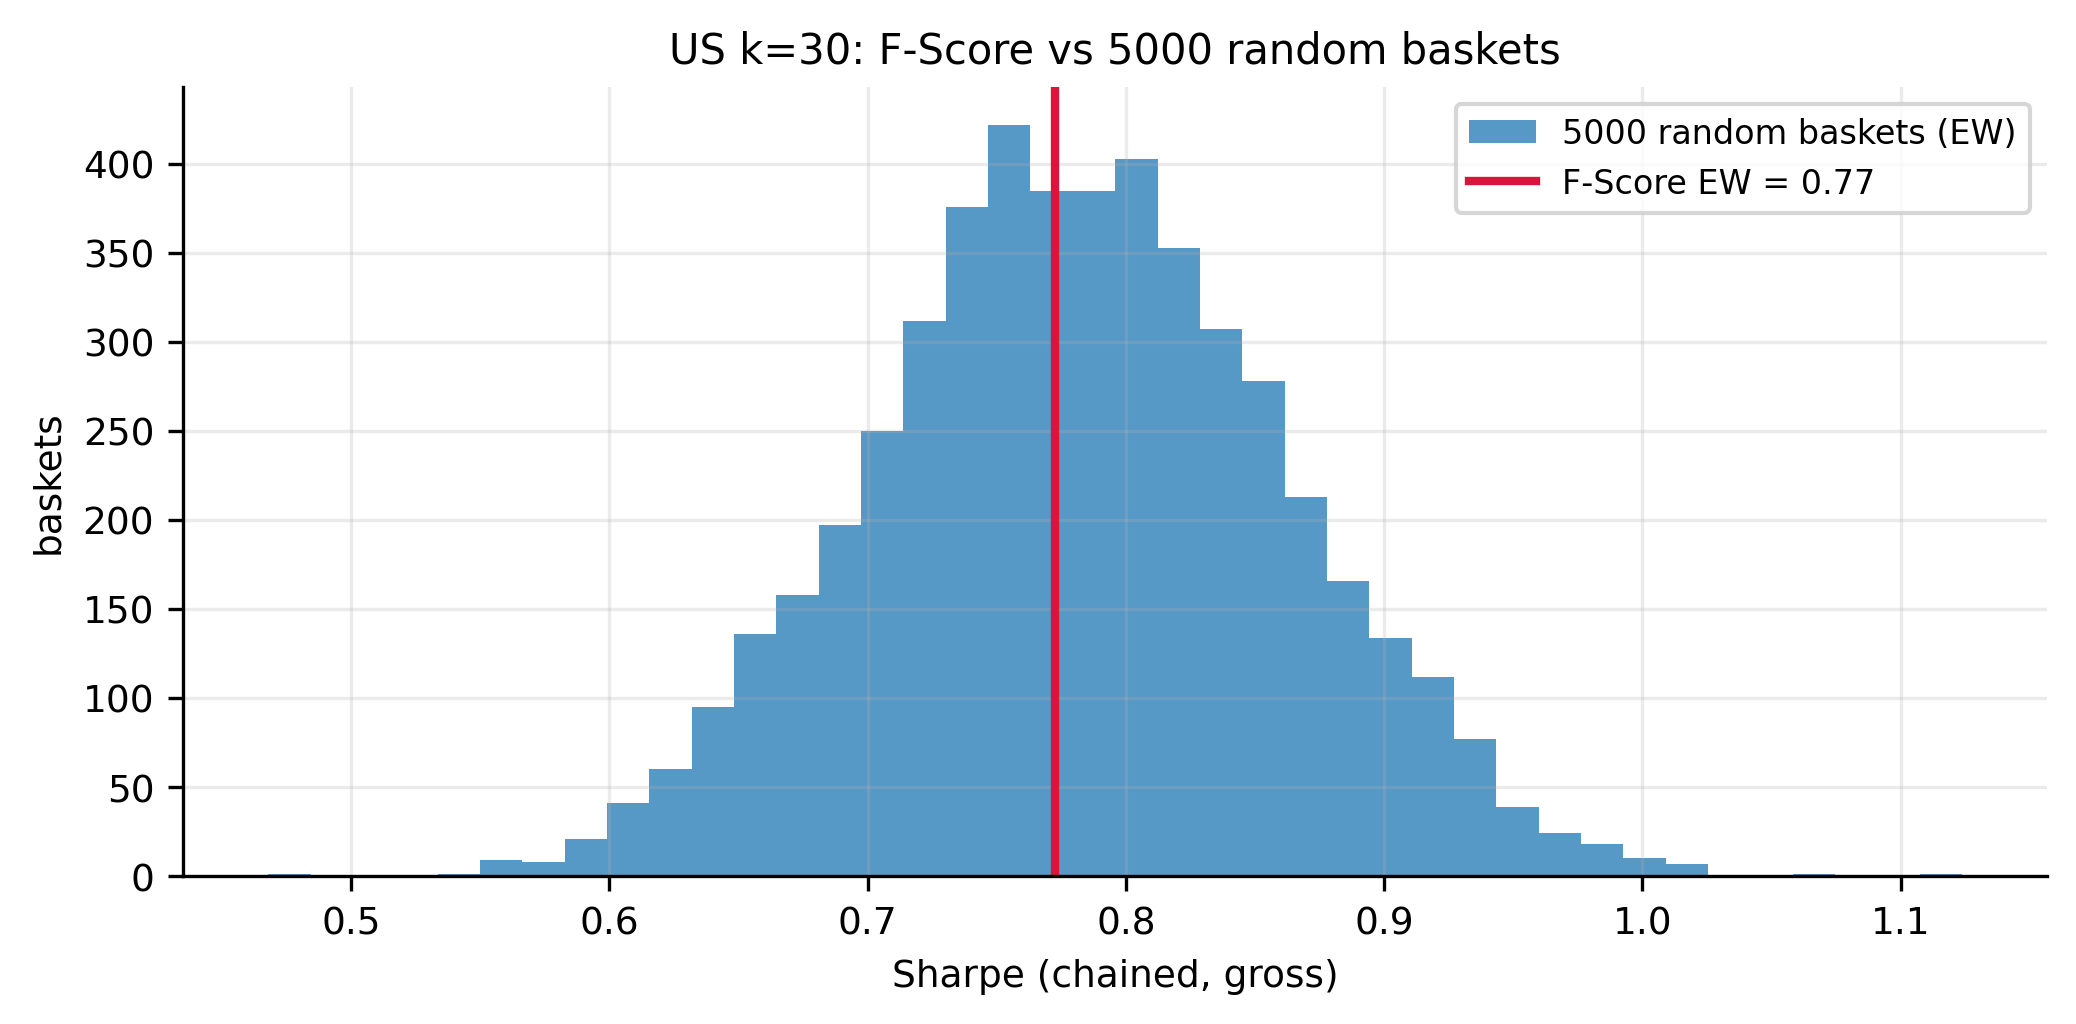

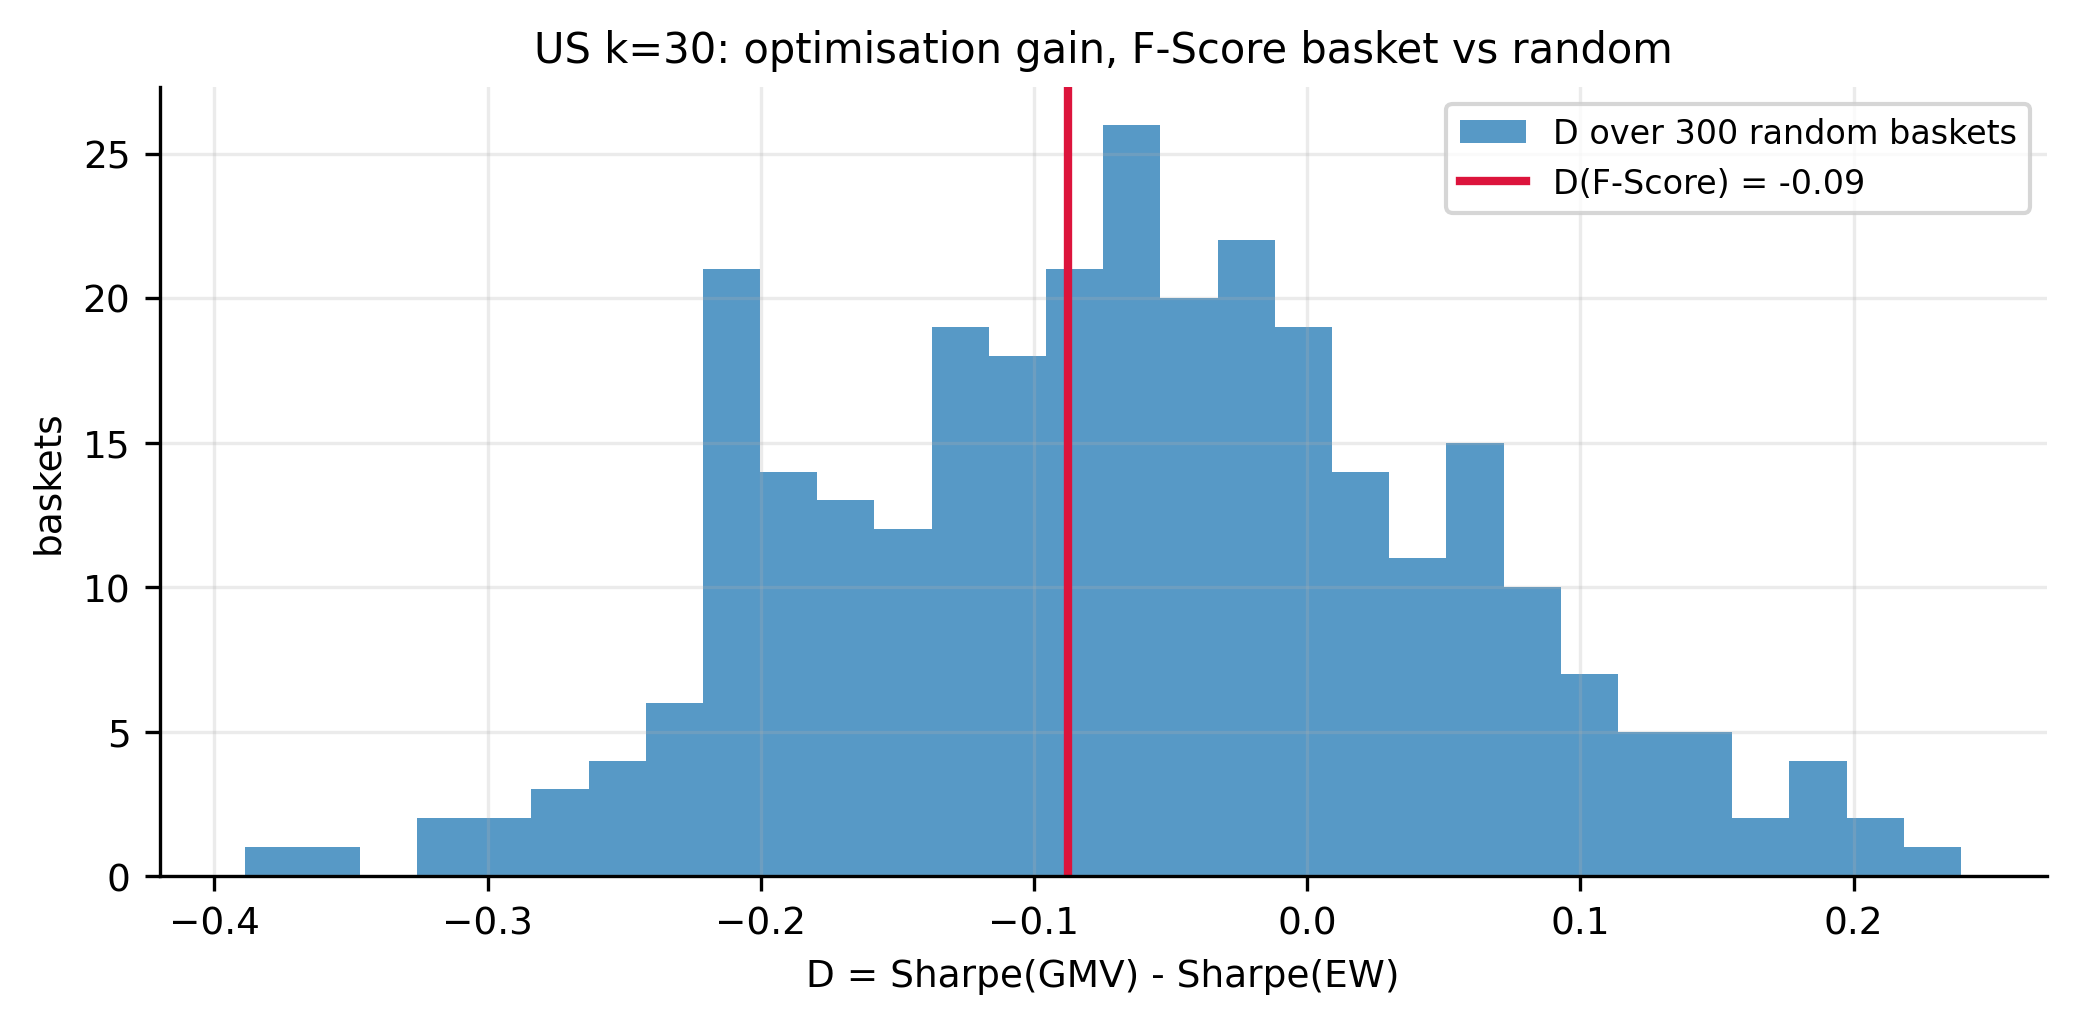

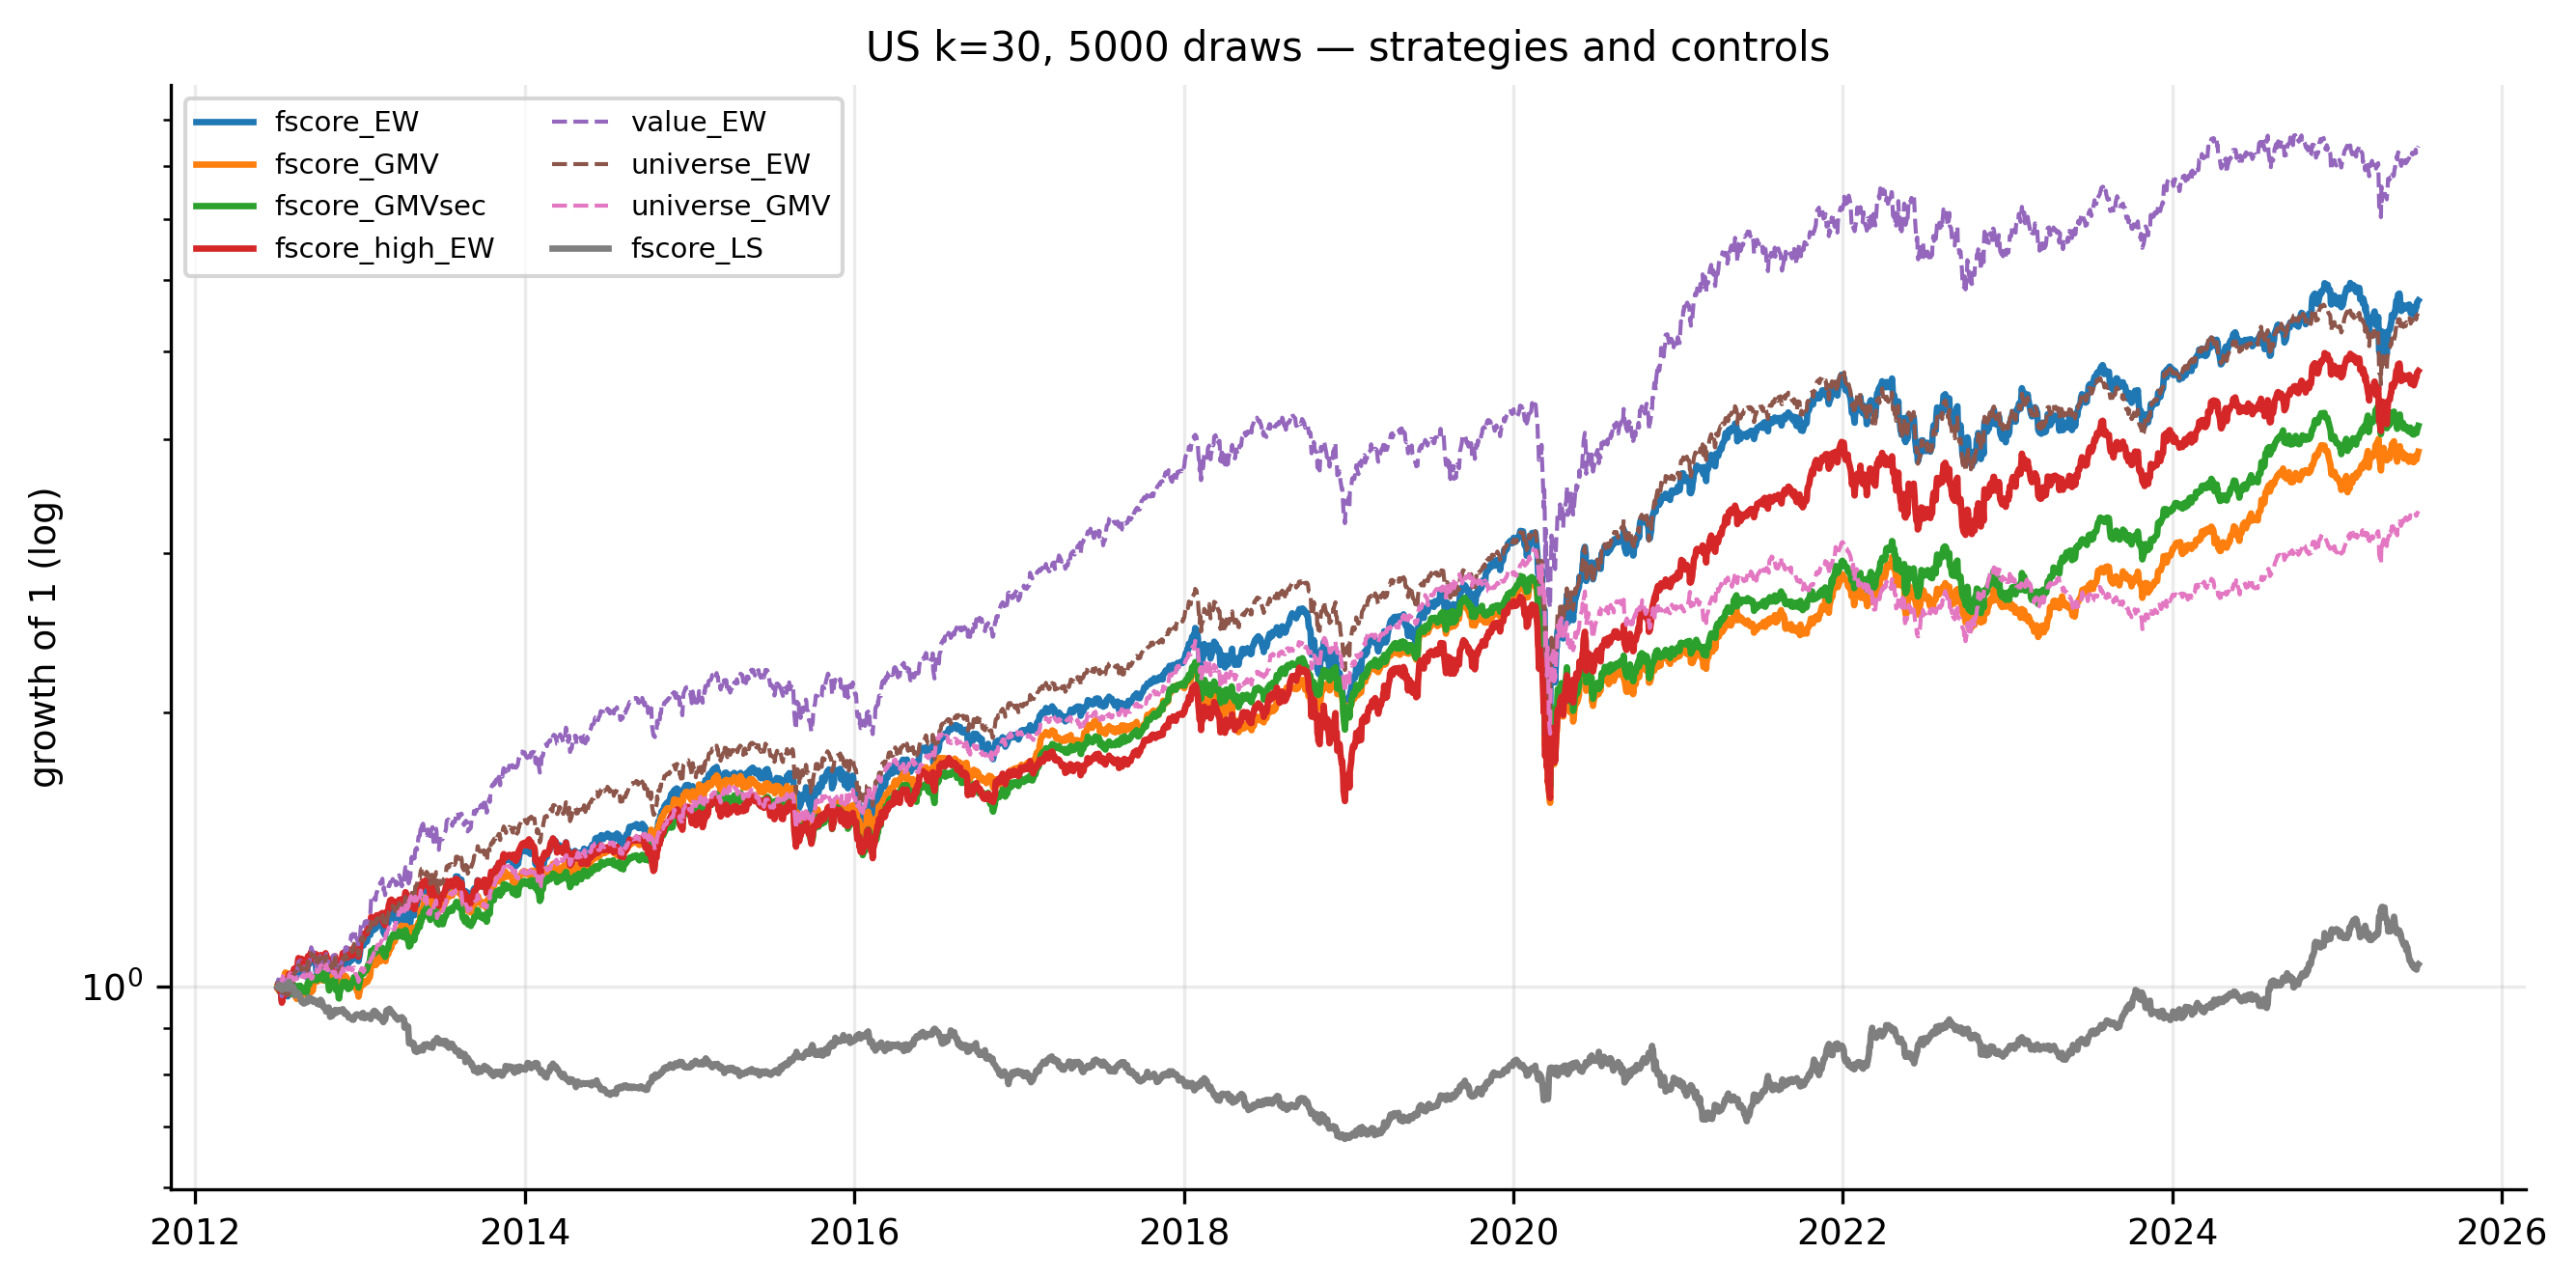

In [10]:
from IPython.display import Image, display
k, n = REF
for suffix in ["mc_hist", "synergy_hist", "nav"]:
    display(Image(filename=str(FIG / f"{MARKET}_k{k}_mc{n}_{suffix}.png"), width=640))

### 4. The consolidated grid

One row per cell. This is what the grid was built to show: whether the
conclusion moves with the basket size or with the number of random draws.

`N` should not move anything but the resolution of the p-value — the same
seed draws the same first 1,000 baskets whether the run asks for 1,000 or
5,000 — so any drift down an `N` block is Monte-Carlo noise, not a finding.
Movement across `k` blocks is the real sensitivity.

In [11]:
rows = []
for (k, n_mc), (st, summ, place, sy, yr, dg) in cells_out.items():
    pl = place.loc[("random (full universe)", "sharpe", "gross")]
    rows.append({
        "mkt": MARKET, "k": k, "N": n_mc,
        "EW": round(float(summ.loc["fscore_EW", "sharpe"]), 4),
        "uniEW": round(float(summ.loc["universe_EW", "sharpe"]), 4)
                 if "universe_EW" in summ.index else np.nan,
        "value": round(float(summ.loc["value_EW", "sharpe"]), 4)
                 if "value_EW" in summ.index else np.nan,
        "to_EW": round(float(summ.loc["fscore_EW", "turnover"]), 4),
        "effN_GMV": round(float(summ.loc["fscore_GMV", "effective_n"]), 4)
                    if "fscore_GMV" in summ.index else np.nan,
        "pct": round(float(pl["percentile"]), 4),
        "p": round(float(pl["p_value"]), 4),
        "sig": bool(pl["significant"]),
        "D": round(float(sy["D_fscore"]), 4),
        "D_p": round(float(sy["p_value"]), 4),
    })
grid = pd.DataFrame(rows).sort_values(["k", "N"]).reset_index(drop=True)
grid.to_csv(OUT / f"{MARKET}_grid_summary.csv", index=False)
grid

,mkt,k,N,EW,uniEW,value,to_EW,effN_GMV,pct,p,sig,D,D_p
0,us,20,1000,0.7218,0.8131,0.9884,0.8685,5.0217,0.3240,0.6760,False,-0.1006,0.5967
1,us,20,2000,0.7218,0.8131,0.9884,0.8685,5.0217,0.3245,0.6755,False,-0.1006,0.5967
2,us,20,5000,0.7218,0.8131,0.9884,0.8685,5.0217,0.3340,0.6660,False,-0.1006,0.5967
3,us,25,1000,0.7040,0.8131,0.9288,0.8515,5.8932,0.2050,0.7950,False,-0.0712,0.5333
4,us,25,2000,0.7040,0.8131,0.9288,0.8515,5.8932,0.2065,0.7935,False,-0.0712,0.5333
5,us,25,5000,0.7040,0.8131,0.9288,0.8515,5.8932,0.2150,0.7850,False,-0.0712,0.5333
6,us,30,1000,0.7726,0.8131,0.8985,0.8369,6.7984,0.4720,0.5280,False,-0.0875,0.5900
7,us,30,2000,0.7726,0.8131,0.8985,0.8369,6.7984,0.4750,0.5250,False,-0.0875,0.5900
8,us,30,5000,0.7726,0.8131,0.8985,0.8369,6.7984,0.4640,0.5360,False,-0.0875,0.5900


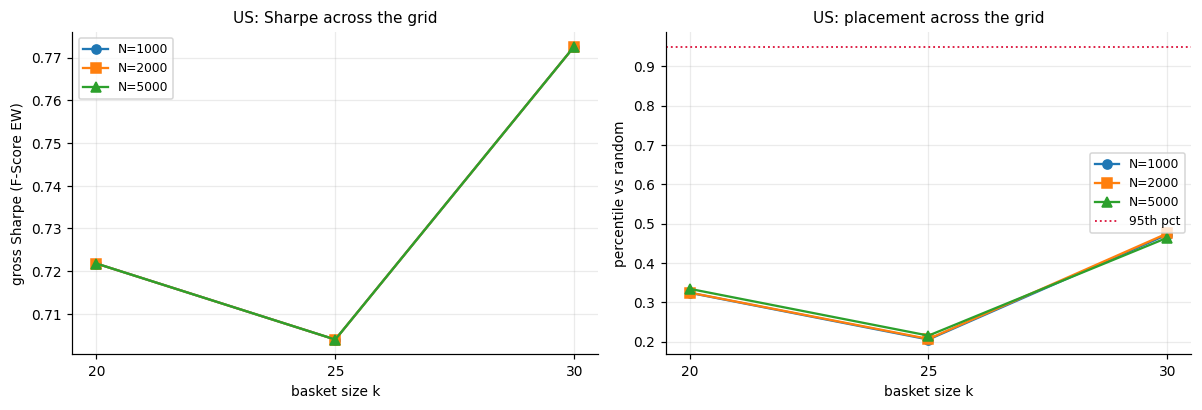

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for n_mc, mark in zip(MCS, ["o", "s", "^"]):
    sub = grid[grid.N == n_mc]
    axes[0].plot(sub.k, sub.EW, mark + "-", label=f"N={n_mc}")
    axes[1].plot(sub.k, sub.pct, mark + "-", label=f"N={n_mc}")
axes[0].set_xlabel("basket size k"); axes[0].set_ylabel("gross Sharpe (F-Score EW)")
axes[0].set_title(f"{MARKET.upper()}: Sharpe across the grid")
axes[1].axhline(0.95, color="crimson", ls=":", lw=1.2, label="95th pct")
axes[1].set_xlabel("basket size k"); axes[1].set_ylabel("percentile vs random")
axes[1].set_title(f"{MARKET.upper()}: placement across the grid")
for a in axes:
    a.set_xticks(KS); a.legend(fontsize=8)
plt.tight_layout(); save_fig(f"{MARKET}_grid_sensitivity", directory=FIG); plt.show()

### 5. Outputs

Each cell's five CSVs and four figures are already on disk under its own
`{market}_k{k}_mc{N}_*` tag — unchanged from when every cell was its own
notebook. This notebook adds one file the eighteen never produced: the
consolidated `{market}_grid_summary.csv` above, which used to be assembled by
hand.

In [13]:
print(f"per-cell outputs : results/grid/{MARKET}_k*_mc*_*.csv  "
      f"({len(cells_out) * 6} files)")
print(f"per-cell figures : results/figures/{MARKET}_k*_mc*_*.png  "
      f"({len(cells_out) * 4} files)")
print(f"consolidated     : results/grid/{MARKET}_grid_summary.csv")

per-cell outputs : results/grid/us_k*_mc*_*.csv  (54 files)
per-cell figures : results/figures/us_k*_mc*_*.png  (36 files)
consolidated     : results/grid/us_grid_summary.csv
